In [1]:
!pip install torch torchvision h5py numpy matplotlib scikit-learn tqdm geopandas rasterio -q

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    # Test moving a tensor to GPU
    x = torch.randn(2, 3).to(device)
    print("Tensor moved to GPU:", x.device)
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU.")

GPU is available: Tesla T4
Tensor moved to GPU: cuda:0


In [7]:
import os
import h5py
import numpy as np

BASE_DIR = "/content/s1s2_data/s1s2_landslide_reference_data/reference_data"

TRAIN_FILE = os.path.join(BASE_DIR, "train_n3_s1s2.h5")
VAL_FILE   = os.path.join(BASE_DIR, "val_n3_s1s2.h5")
TEST_FILE  = os.path.join(BASE_DIR, "testind_n3_s1s2.h5")

print(os.path.exists(TRAIN_FILE), TRAIN_FILE)
print(os.path.exists(VAL_FILE), VAL_FILE)
print(os.path.exists(TEST_FILE), TEST_FILE)

True /content/s1s2_data/s1s2_landslide_reference_data/reference_data/train_n3_s1s2.h5
True /content/s1s2_data/s1s2_landslide_reference_data/reference_data/val_n3_s1s2.h5
True /content/s1s2_data/s1s2_landslide_reference_data/reference_data/testind_n3_s1s2.h5


In [8]:
with h5py.File(TRAIN_FILE, "r") as f:
    print("Keys:", list(f.keys()))

    for k in f.keys():
        print(k, f[k].shape, f[k].dtype)

Keys: ['None_DEM', 'None_MASK', 'None_SLOPE', 'POST1_ALPHA', 'POST1_ANISOTROPY', 'POST1_B02', 'POST1_B03', 'POST1_B04', 'POST1_B05', 'POST1_B06', 'POST1_B07', 'POST1_B08', 'POST1_B11', 'POST1_B12', 'POST1_B8A', 'POST1_COHVV', 'POST1_ENTROPY', 'POST1_NDVI', 'POST1_gVH', 'POST1_gVV', 'POST2_ALPHA', 'POST2_ANISOTROPY', 'POST2_COHVV', 'POST2_ENTROPY', 'POST2_gVH', 'POST2_gVV', 'POST3_ALPHA', 'POST3_ANISOTROPY', 'POST3_COHVV', 'POST3_ENTROPY', 'POST3_gVH', 'POST3_gVV', 'PRE1_ALPHA', 'PRE1_ANISOTROPY', 'PRE1_B02', 'PRE1_B03', 'PRE1_B04', 'PRE1_B05', 'PRE1_B06', 'PRE1_B07', 'PRE1_B08', 'PRE1_B11', 'PRE1_B12', 'PRE1_B8A', 'PRE1_COHVV', 'PRE1_ENTROPY', 'PRE1_NDVI', 'PRE1_gVH', 'PRE1_gVV', 'PRE2_ALPHA', 'PRE2_ANISOTROPY', 'PRE2_COHVV', 'PRE2_ENTROPY', 'PRE2_gVH', 'PRE2_gVV', 'PRE3_ALPHA', 'PRE3_ANISOTROPY', 'PRE3_ENTROPY', 'PRE3_gVH', 'PRE3_gVV']
None_DEM (355, 1, 128, 128) float32
None_MASK (355, 1, 128, 128) float32
None_SLOPE (355, 1, 128, 128) float32
POST1_ALPHA (355, 1, 128, 128) float32
P

In [24]:
import os
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class LandslideH5Dataset(torch.utils.data.Dataset):
    def __init__(self, file_path):
        self.file_path = file_path

        with h5py.File(file_path, "r") as f:
            self.keys = list(f.keys())
            self.mask_key = "None_MASK"

            # select useful input bands
            self.input_keys = [
                k for k in self.keys
                if k != self.mask_key
            ]

        print(f"Initialized dataset from {file_path}. Total input channels: {len(self.input_keys)}")
        print("Example input keys:", self.input_keys[:5])

    def __len__(self):
        with h5py.File(self.file_path, "r") as f:
            return f[self.mask_key].shape[0]

    def __getitem__(self, idx):
        with h5py.File(self.file_path, "r") as f:

            # build multi-channel input stack
            bands = []
            for k in self.input_keys:
                arr = f[k][idx]

                if arr.ndim == 2:
                    arr = arr[np.newaxis, ...]

                bands.append(arr)

            img = np.concatenate(bands, axis=0)

            mask = f[self.mask_key][idx]

        # ---------------- IMAGE ----------------
        img = img.astype(np.float32)

        img_min, img_max = img.min(), img.max()
        img = (img - img_min) / (img_max - img_min + 1e-6)

        # ---------------- MASK ----------------
        mask = (mask > 0).astype(np.int64)

        # 🔥 FIX: ensure mask is (H, W), NOT (1, H, W)
        mask = np.squeeze(mask)

        if mask.ndim == 3:
            mask = mask[0]

        if mask.ndim != 2:
            raise ValueError(f"Invalid mask shape after processing: {mask.shape}")

        return torch.tensor(img), torch.tensor(mask)

In [23]:
imgs, masks = next(iter(train_loader))

print("Image:", imgs.shape)
print("Mask :", masks.shape)

Image: torch.Size([4, 59, 128, 128])
Mask : torch.Size([4, 1, 128, 128])


In [25]:
train_dataset = LandslideH5Dataset(TRAIN_FILE)
val_dataset   = LandslideH5Dataset(VAL_FILE)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False)

sample_img, sample_mask = train_dataset[0]

IN_CHANNELS = sample_img.shape[0]

print("Final input channels:", IN_CHANNELS)
print("Image shape:", sample_img.shape)

Initialized dataset from /content/s1s2_data/s1s2_landslide_reference_data/reference_data/train_n3_s1s2.h5. Total input channels: 59
Example input keys: ['None_DEM', 'None_SLOPE', 'POST1_ALPHA', 'POST1_ANISOTROPY', 'POST1_B02']
Initialized dataset from /content/s1s2_data/s1s2_landslide_reference_data/reference_data/val_n3_s1s2.h5. Total input channels: 59
Example input keys: ['None_DEM', 'None_SLOPE', 'POST1_ALPHA', 'POST1_ANISOTROPY', 'POST1_B02']
Final input channels: 59
Image shape: torch.Size([59, 128, 128])


In [26]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, 2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        self.inc   = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)

        self.outc = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)

        return self.outc(x)

In [27]:
model = UNet(in_channels=IN_CHANNELS, num_classes=2).to(device)

In [28]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [29]:
def compute_iou(pred, mask):
    pred = pred.flatten()
    mask = mask.flatten()

    intersection = (pred & mask).sum()
    union = (pred | mask).sum()

    return intersection / (union + 1e-6)

In [30]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    ious = []

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        for p, m in zip(preds, masks):
            ious.append(compute_iou(p.cpu().numpy(), m.cpu().numpy()))

    return total_loss / len(loader), np.mean(ious)

In [35]:
imgs, masks = next(iter(train_loader))

print("IMAGE:", imgs.shape)   # expected (B, 59, 128, 128)
print("MASK :", masks.shape)   # expected (B, 128, 128)

IMAGE: torch.Size([4, 59, 128, 128])
MASK : torch.Size([4, 128, 128])


In [36]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    ious = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            for p, m in zip(preds, masks):
                ious.append(compute_iou(p.cpu().numpy(), m.cpu().numpy()))

    return total_loss / len(loader), np.mean(ious)

In [37]:
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_iou     = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val IoU  : {val_iou:.4f}")
    print("-"*40)

Epoch 1
Train Loss: 0.1798 | Train IoU: 0.4704
Val Loss  : 0.1528 | Val IoU  : 0.4826
----------------------------------------
Epoch 2
Train Loss: 0.1661 | Train IoU: 0.4804
Val Loss  : 0.1736 | Val IoU  : 0.3735
----------------------------------------
Epoch 3
Train Loss: 0.1467 | Train IoU: 0.5038
Val Loss  : 0.1314 | Val IoU  : 0.3784
----------------------------------------
Epoch 4
Train Loss: 0.1317 | Train IoU: 0.5334
Val Loss  : 0.1466 | Val IoU  : 0.5614
----------------------------------------
Epoch 5
Train Loss: 0.1220 | Train IoU: 0.5465
Val Loss  : 0.1055 | Val IoU  : 0.5031
----------------------------------------
Epoch 6
Train Loss: 0.1326 | Train IoU: 0.5312
Val Loss  : 0.1117 | Val IoU  : 0.4507
----------------------------------------
Epoch 7
Train Loss: 0.1147 | Train IoU: 0.5484
Val Loss  : 0.1061 | Val IoU  : 0.4974
----------------------------------------
Epoch 8
Train Loss: 0.1185 | Train IoU: 0.5531
Val Loss  : 0.1017 | Val IoU  : 0.5348
-------------------------

In [38]:
import numpy as np
import torch

def evaluate_model(model, loader, device):
    model.eval()

    TP = 0
    FP = 0
    FN = 0
    TN = 0

    total_correct = 0
    total_pixels = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            preds = preds.cpu().numpy().flatten()
            masks = masks.cpu().numpy().flatten()

            TP += np.sum((preds == 1) & (masks == 1))
            FP += np.sum((preds == 1) & (masks == 0))
            FN += np.sum((preds == 0) & (masks == 1))
            TN += np.sum((preds == 0) & (masks == 0))

            total_correct += np.sum(preds == masks)
            total_pixels += len(masks)

    # ---- METRICS ----
    pixel_acc = total_correct / total_pixels

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    iou       = TP / (TP + FP + FN + 1e-8)

    # background + class mean IoU (binary case simplified)
    miou = (iou + (TN / (TN + FP + FN + 1e-8))) / 2

    print("\n===== FINAL U-NET METRICS =====")
    print(f"Pixel Accuracy : {pixel_acc:.4f}")
    print(f"IoU (Landslide): {iou:.4f}")
    print(f"Mean IoU       : {miou:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")

    return {
        "pixel_acc": pixel_acc,
        "iou": iou,
        "miou": miou,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# RUN IT
results = evaluate_model(model, val_loader, device)


===== FINAL U-NET METRICS =====
Pixel Accuracy : 0.9775
IoU (Landslide): 0.8044
Mean IoU       : 0.8898
Precision      : 0.9269
Recall         : 0.8588
F1 Score       : 0.8916


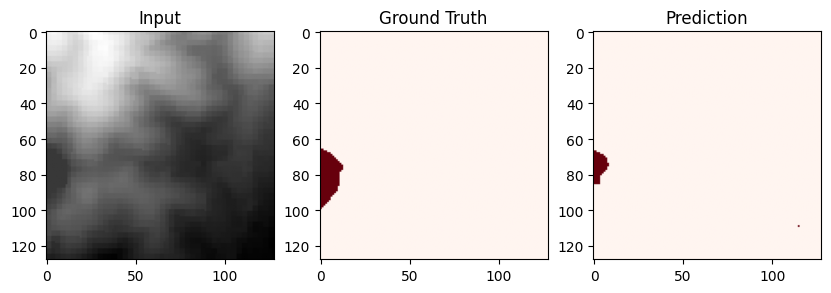

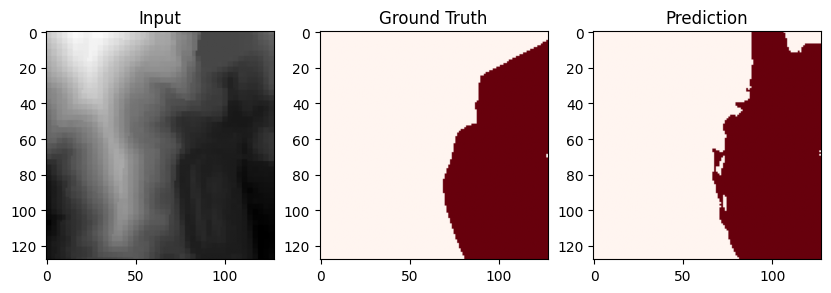

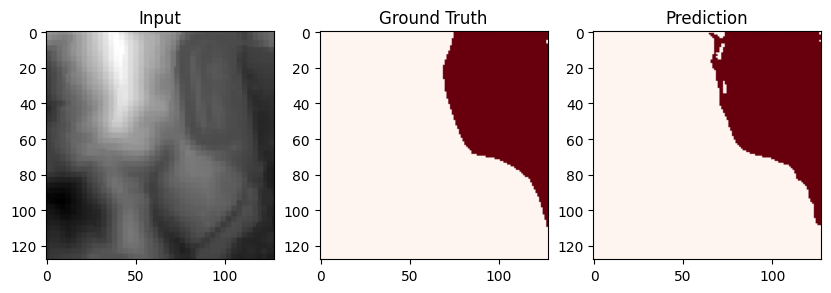

In [39]:
import matplotlib.pyplot as plt

def visualize(model, dataset, device, n=3):
    model.eval()

    for i in range(n):
        img, mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

        img = img[0].cpu().numpy()  # show first channel

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Input")
        plt.imshow(img, cmap='gray')

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap='Reds')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap='Reds')

        plt.show()


visualize(model, val_dataset, device)